# Libraries & Import file

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

In [32]:
df = pd.read_csv("../data/adult.csv")

# Data Understanding

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.shape

(32561, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

**handle missing value**

In [33]:
df.replace("?", np.nan, inplace=True)

In [34]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [35]:
df.dropna(inplace=True)

In [36]:
df.drop("fnlwgt", axis=1, inplace=True)

# EDA & Visualization

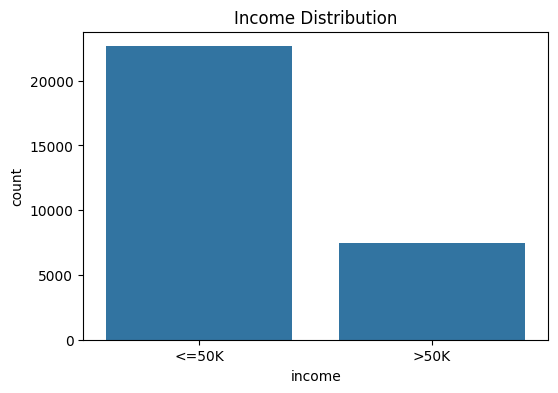

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

Most people have an income of ≤50K

There's an imbalance in the data.

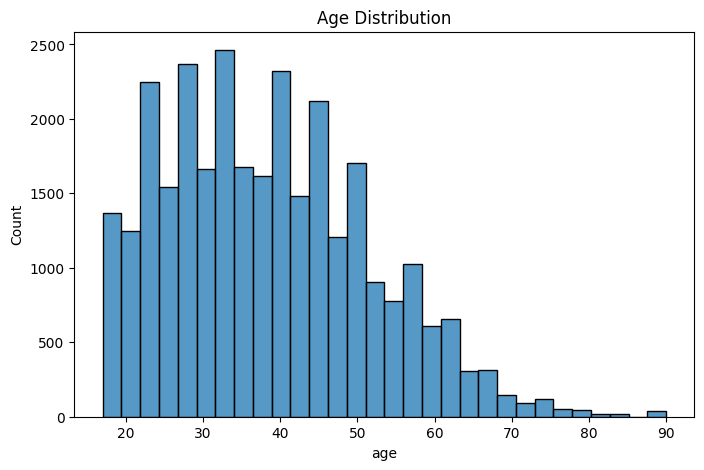

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

Most ages are between 25 and 50 years old

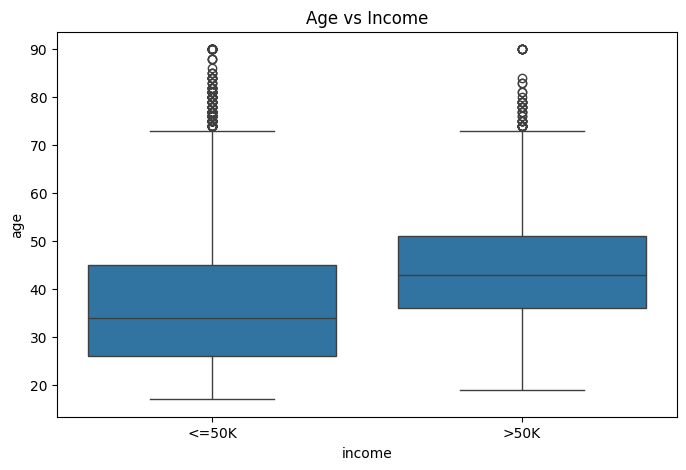

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x="income", y="age", data=df)
plt.title("Age vs Income")
plt.show()

Older people often have higher incomes.

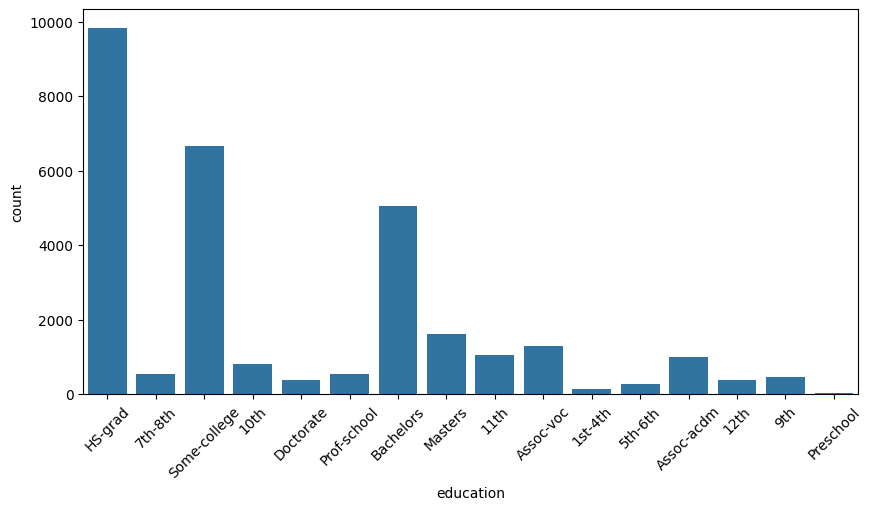

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(x="education", data=df)
plt.xticks(rotation=45)
plt.show()

The most common level of education is High School.

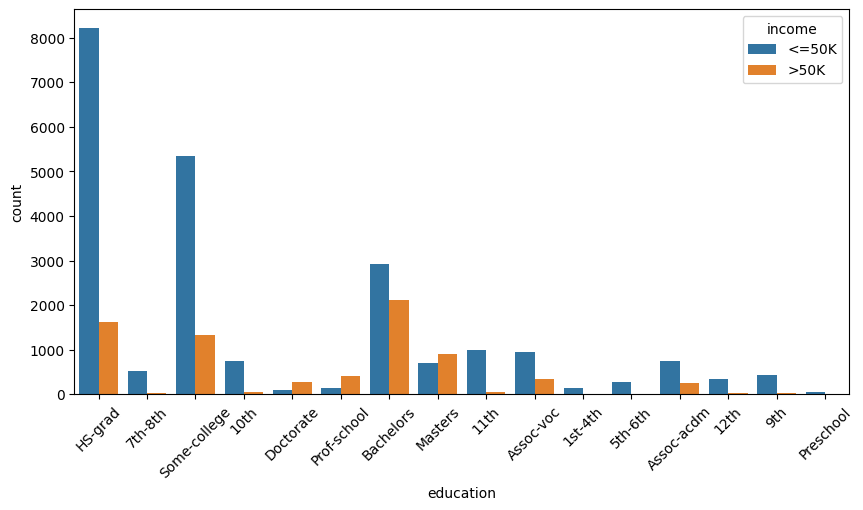

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(x="education", hue="income", data=df)
plt.xticks(rotation=45)
plt.show()

Bachelor's/Master's degrees often have higher incomes.

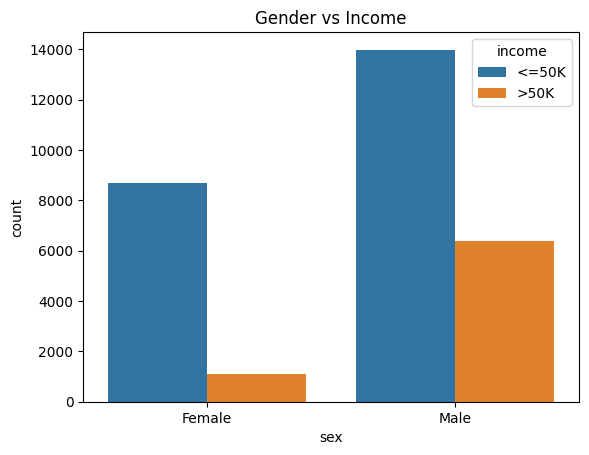

In [42]:
sns.countplot(x="sex", hue="income", data=df)
plt.title("Gender vs Income")
plt.show()

Males have a higher proportion in the highest income bracket.

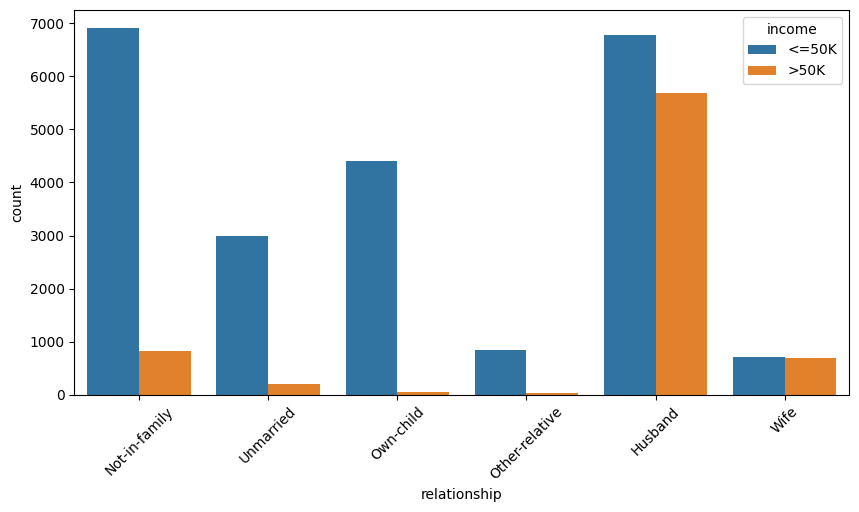

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(x="relationship", hue="income", data=df)
plt.xticks(rotation=45)
plt.show()

Married and not in family people often have higher incomes.

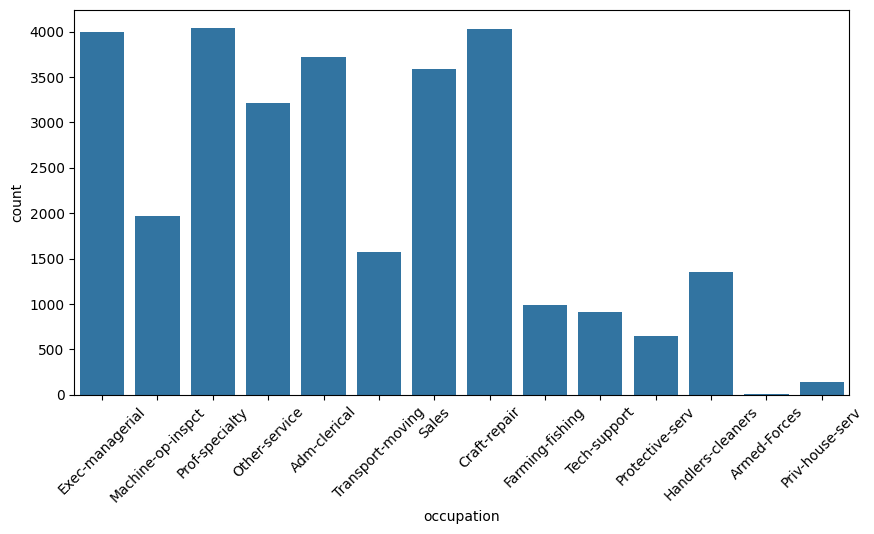

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x="occupation", data=df)
plt.xticks(rotation=45)
plt.show()

show highest jobs

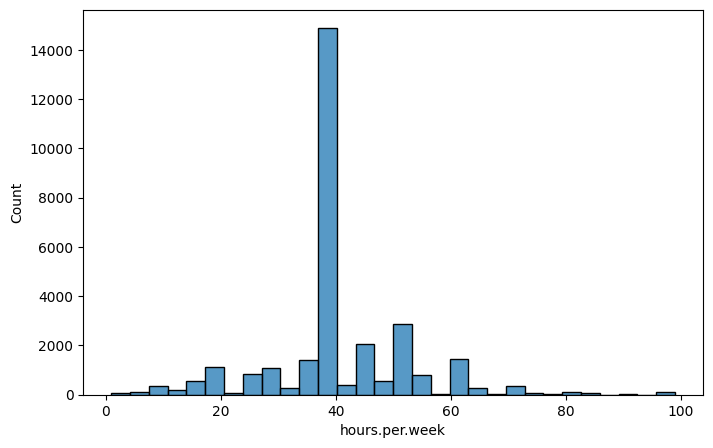

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df["hours.per.week"], bins=30)
plt.show()

Most people work around 40 hours a week.

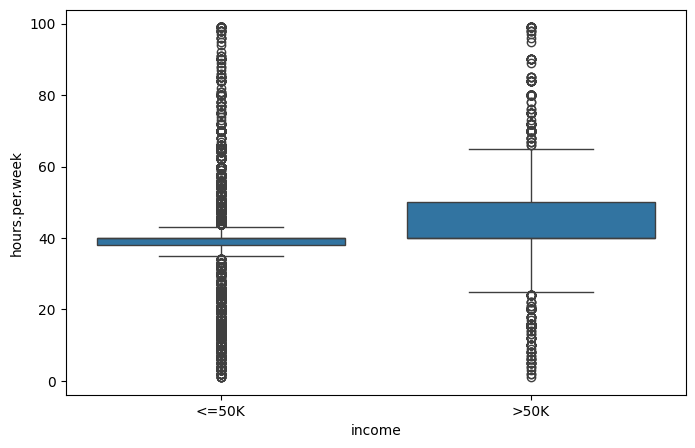

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x="income", y="hours.per.week", data=df)
plt.show()

People who work longer hours often earn higher wages.

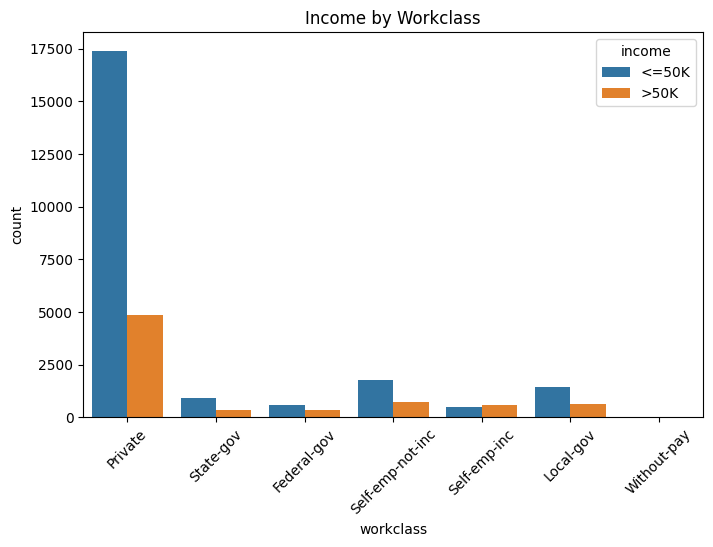

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(x="workclass", hue="income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Workclass")
plt.show()

Some types of work, like private, have a higher percentage of higher income.

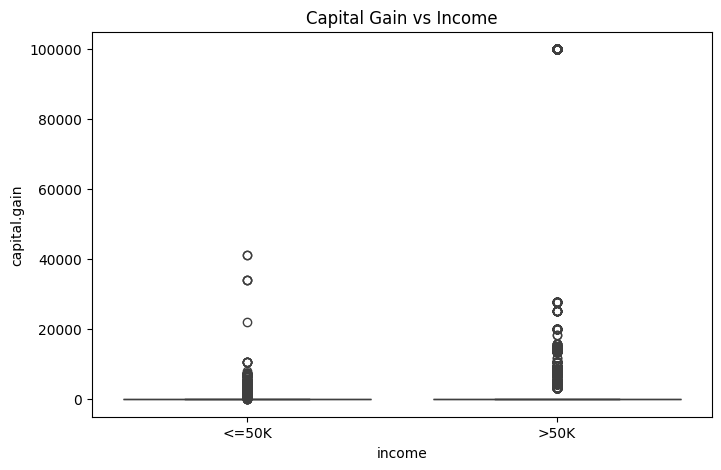

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x="income", y="capital.gain", data=df)
plt.title("Capital Gain vs Income")
plt.show()

People with high capital gain often have an income >50K.

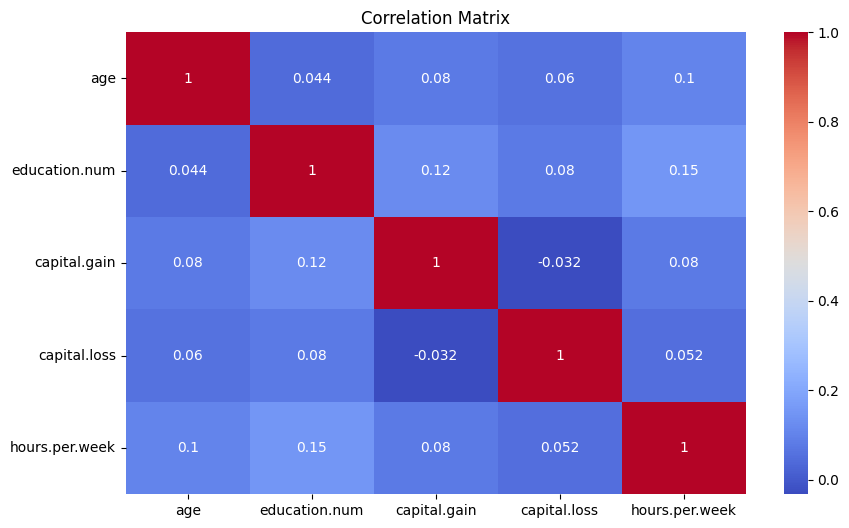

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Preprocessing

**Target**

In [50]:
X = df.drop("income", axis=1)
y = df["income"]

**Numerical features**

In [51]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns

**Categorical features**

In [52]:
cat_cols = X.select_dtypes(include=["object"]).columns

**One-Hot Encoding**

In [53]:
X = pd.get_dummies(X, drop_first=True)

In [54]:
y = y.map({"<=50K":0, ">50K":1})

**Train Test Split**

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**
عملته احتياطي

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [59]:
# **Save preprocessed data**
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)